In [1]:
import numpy as np
import pandas as pd

In [8]:
np.random.seed(23)

mu_vec1 = np.array([0,0,0])
cov_mat1 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)

df = pd.DataFrame(class1_sample,columns=['feature1','feature2','feature3'])
df['target'] = 1

mu_vec2 = np.array([1,1,1])
cov_mat2 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)

df1 = pd.DataFrame(class2_sample,columns=['feature1','feature2','feature3'])
df['target'] = 0

import pandas as pd

df = pd.concat([df, df1], ignore_index=True)
df  = df.sample(40)



In [9]:
df.head()

,feature1,feature2,feature3,target
2,-0.367548,-1.137460,-1.322148,0.0
34,0.177061,-0.598109,1.226512,NaN
14,0.420623,0.411620,-0.071324,0.0
11,1.968435,-0.547788,-0.679418,0.0
12,-2.506230,0.146960,0.606195,0.0


In [10]:
import plotly.express as px
#y_train_trf = y_train.astype(str)
fig = px.scatter_3d(df, x=df['feature1'], y=df['feature2'], z=df['feature3'],
                                  color=df['target'].astype('str'))
fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                                    selector=dict(mode='markers'))
fig.show()


In [13]:
# step 1 Applying standard scaling

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df.iloc[:,0:3] - scaler.fit_transform(df.iloc[:,0:3])

,feature1,feature2,feature3
2,0.333261,0.388127,0.427009
34,0.401542,0.412648,0.735260
14,0.432079,0.458554,0.578292
11,0.626139,0.414935,0.504745
12,0.065120,0.446522,0.660235
29,0.558022,0.505361,0.608998
31,0.658235,0.450315,0.731101
4,0.419748,0.442584,0.460716
32,0.288664,0.506275,0.576593
33,0.733329,0.424707,0.905901


In [14]:
# Step 2 - Find Covariance Matrix
covariance_matrix = np.cov([df.iloc[:,0],df.iloc[:,1],df.iloc[:,2]])
print('Covariance Matrix:\n', covariance_matrix)

Covariance Matrix:
 [[1.34076734 0.24528825 0.10420627]
 [0.24528825 1.12566959 0.23643388]
 [0.10420627 0.23643388 1.327287  ]]


In [15]:
# step 3 - finding Ev and Evs
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)

In [16]:
eigen_values

array([1.65691289, 1.22963722, 0.90717381])

In [17]:
eigen_vectors

array([[-0.61002583, -0.69239396,  0.3853039 ],
       [-0.53982115,  0.00718615, -0.84174906],
       [-0.58005311,  0.72148387,  0.37815264]])

Populating the interactive namespace from numpy and matplotlib


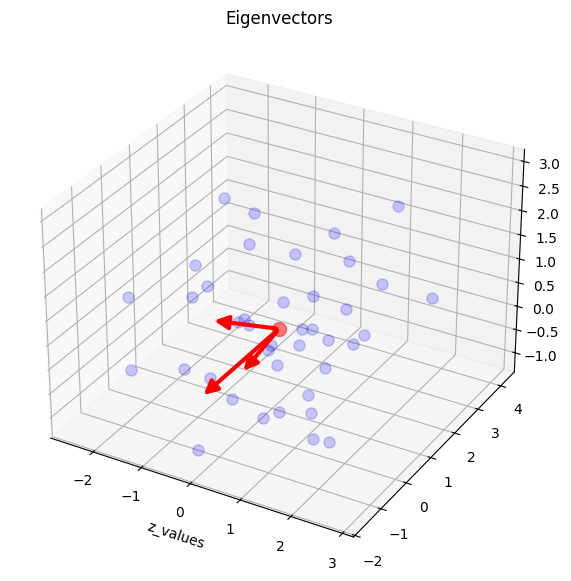

In [19]:
%pylab inline
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d import proj3d
from matplotlib.patches import FancyArrowPatch

from mpl_toolkits.mplot3d import proj3d
from matplotlib.patches import FancyArrowPatch

class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        super().__init__((0,0), (0,0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def do_3d_projection(self, renderer=None):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.M)
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        return zs.min()
fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')

ax.plot(df['feature1'], df['feature2'], df['feature3'], 'o', markersize=8, color='blue', alpha=0.2)
ax.plot([df['feature1'].mean()], [df['feature2'].mean()], [df['feature3'].mean()], 'o', markersize=10, color='red', alpha=0.5)
for v in eigen_vectors.T:
      a = Arrow3D([df['feature1'].mean(), v[0]], [df['feature2'].mean(), v[1]], [df['feature3'].mean(), v[2]], mutation_scale=20, lw=3, arrowstyle="-|>", color="r")
      ax.add_artist(a)
ax.set_xlabel('x_values')
ax.set_xlabel('y_values')
ax.set_xlabel('z_values')

plt.title('Eigenvectors')

plt.show()


In [20]:
pc = eigen_vectors[0:2]
pc

array([[-0.61002583, -0.69239396,  0.3853039 ],
       [-0.53982115,  0.00718615, -0.84174906]])

In [21]:
transformed_df = np.dot(df.iloc[:,0:3],pc.T)
# 40,3 - 3,2
new_df = pd.DataFrame(transformed_df,columns=['PC1','PC2'])
new_df['target'] = df['target'].values
new_df.head()

,PC1,PC2,target
0,0.502355,1.303153,0.0
1,0.778695,-1.132295,NaN
2,-0.569075,-0.164066,0.0
3,-1.083293,-0.494640,0.0
4,1.660680,0.843708,0.0


In [22]:
new_df['target'] = new_df['target'].astype('str')
fig = px.scatter(x=new_df['PC1'],
                y=new_df['PC2'],
                color=new_df['target'],
                color_discrete_sequence=px.colors.qualitative.G10
)
fig.update_traces(marker=dict(size=12,
                             line=dict(width=2,
                            color='DarkSlateGrey')),
                                    selector=dict(mode='markers'))
fig.show()
